## Stacked barplots

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Loading the data
df = pd.read_csv('results.csv')

def plot_cost_comparison(df_subset, x_label_col, title, save_path):
    cost_cols = ['storage_chf', 'requests_chf', 'transfer_chf']
    
    df_plot = df_subset.set_index(x_label_col)[cost_cols]

    ax = df_plot.plot(
        kind='bar', 
        stacked=True, 
        figsize=(10, 6), 
        color=['#3498db', '#e67e22', '#2ecc71']
    )
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel('Total Cost (CHF)', fontsize=12)
    plt.xlabel('Configuration', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.legend(title="Cost Breakdown", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

# --- COMPARISON 1: CSV vs Parquet (Across S, M, L) ---
csv_vs_pq = df[(df['n_files'] == 1) & ((df['variant'] == 'raw') | ((df['variant'] == 'parquet') & (df['compression'].isin(['none', None]))))]

csv_vs_pq['label_variant'] = csv_vs_pq['label'] + " (" + csv_vs_pq['variant'] + ")"

plot_cost_comparison(
    csv_vs_pq, 
    'label_variant', 
    'Cost Comparison: CSV vs Parquet (S, M, L)', 
    'comparison_format.png'
)

# Comparison 2: Snappy vs ZSTD
compression_df = df[
    (df['variant'] == 'parquet') 
    #(df['n_files'] == 1)
].copy()
compression_df['label_variant'] = compression_df['label'] + " (" + compression_df['compression'] + ")"

plot_cost_comparison(
    compression_df, 
    'label_variant', 
    'Cost Comparison: Snappy vs ZSTD', 
    'comparison_compression.png'
)

# Comparison 3: Small Files vs Compact
files_df = df[
    (df['variant'] == 'parquet') &  (df['compression'] == 'none') |(df['variant'] == 'parquet_small')
].copy()
files_df['sizing'] = files_df['n_files'].apply(lambda x: "Small (100k)" if x > 1 else "Compact")

plot_cost_comparison(
    files_df, 
    'sizing', 
    'Cost Comparison: File Segmentation', 
    'comparison_segmentation.png'
)

by_date_df = df[
    ((df['variant'] == 'parquet') & (df['compression'] == "none")) | 
    (df['variant'] == 'parquet_partitioned')].copy()

by_date_df['label_variant'] = by_date_df['label'] + " (" + by_date_df['variant'] + ")"

plot_cost_comparison(
    by_date_df, 
    'label_variant', 
    'Cost Comparison: Partition by Month-year vs Flat', 
    'comparison_partition.png'
)

SyntaxError: invalid syntax (772978917.py, line 57)

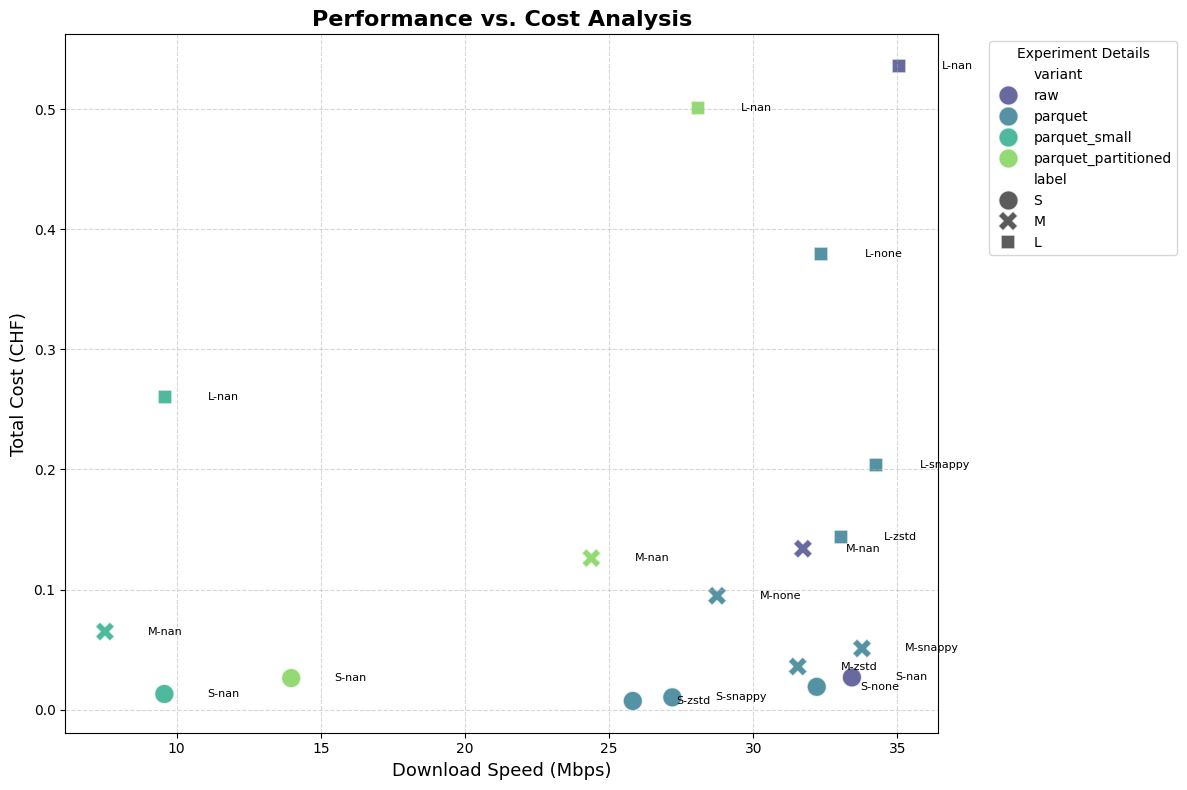

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load your results
# df = pd.read_csv('results.csv')

# 2. Plotting
plt.figure(figsize=(12, 8))

# Use scatterplot to show individual experiment results
sns.scatterplot(
    data=df, 
    x='dl_mbps', 
    y='total_chf', 
    hue='variant',      # Color by Format (CSV vs Parquet)
    style='label',      # Different shapes for S, M, L sizes
    s=200,              # Make the points large and visible
    alpha=0.8,          # Slight transparency for overlapping points
    palette='viridis'   # Professional color palette
)

# 3. Styling and Labels
plt.title('Performance vs. Cost Analysis', fontsize=16, fontweight='bold')
plt.xlabel('Download Speed (Mbps)', fontsize=13)
plt.ylabel('Total Cost (CHF)', fontsize=13)
plt.grid(True, linestyle='--', alpha=0.5)

# Add a legend outside the plot area
plt.legend(title='Experiment Details', bbox_to_anchor=(1.05, 1), loc='upper left')

# 4. Adding Annotations (Optional)
# This adds text labels to the points so you can identify them easily
for i in range(df.shape[0]):
    plt.text(
        df.dl_mbps.iloc[i] + 1.5, 
        df.total_chf.iloc[i], 
        f"{df.label.iloc[i]}-{df.compression.iloc[i]}", 
        fontsize=8, 
        va='center'
    )

plt.tight_layout()
plt.savefig('performance_scatter_plot.png')
plt.show()